IMPORT PYTHON LIBRARIES

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

LOAD THE DATASET AS EXCEL

In [2]:
data=pd.read_excel('/content/ev_charging_dataset_with_added_parameters.xlsx')

EXPLORATORY DATA ANALYSIS

In [3]:
data.shape

(10000, 18)

In [4]:
data.head()

,Station_ID,City,Date,Time_Slot,Vehicle_Type,Battery_Percentage,Charging_Type,Available_Chargers,Vehicles_Waiting,Weather,Temperature,Holiday,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW,Traffic_Level
0,S754,Coimbatore,2025-01-13,Evening,SUV,33,Fast,2,21,Rainy,35,Yes,84,205,4,4,120,Medium
1,S130,Coimbatore,2025-04-22,Afternoon,Car,76,Fast,7,7,Cloudy,36,No,30,17,4,1,150,High
2,S814,Hyderabad,2025-06-24,Evening,SUV,32,Normal,2,2,Cloudy,21,No,74,39,8,7,50,Low
3,S370,Coimbatore,2025-08-24,Morning,Van,15,Normal,6,18,Sunny,40,Yes,35,110,6,3,120,Medium
4,S333,Bengaluru,2025-02-10,Afternoon,Car,53,Normal,8,20,Cloudy,23,No,75,85,6,5,150,Low


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Station_ID          10000 non-null  object
 1   City                10000 non-null  object
 2   Date                10000 non-null  object
 3   Time_Slot           10000 non-null  object
 4   Vehicle_Type        10000 non-null  object
 5   Battery_Percentage  10000 non-null  int64 
 6   Charging_Type       10000 non-null  object
 7   Available_Chargers  10000 non-null  int64 
 8   Vehicles_Waiting    10000 non-null  int64 
 9   Weather             10000 non-null  object
 10  Temperature         10000 non-null  int64 
 11  Holiday             10000 non-null  object
 12  Electricity_Load    10000 non-null  int64 
 13  Waiting_Time        10000 non-null  int64 
 14  Total_Chargers      10000 non-null  int64 
 15  Occupied_Chargers   10000 non-null  int64 
 16  Charging_Power_kW   100

In [6]:
data.describe()

,Battery_Percentage,Available_Chargers,Vehicles_Waiting,Temperature,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.873600,4.491400,12.477000,30.025300,64.570900,116.587100,8.027000,4.010200,84.899800
std,26.268518,2.299838,7.479242,7.189327,20.439147,139.071857,2.825822,3.079585,51.724144
min,5.000000,1.000000,0.000000,18.000000,30.000000,0.000000,4.000000,0.000000,22.000000
25%,27.000000,2.000000,6.000000,24.000000,47.000000,34.000000,6.000000,2.000000,22.000000
50%,50.000000,4.000000,13.000000,30.000000,64.000000,71.000000,8.000000,3.000000,50.000000
75%,73.000000,7.000000,19.000000,36.000000,82.000000,138.000000,10.000000,6.000000,150.000000
max,95.000000,8.000000,25.000000,42.000000,100.000000,880.000000,12.000000,12.000000,150.000000


In [7]:
data.columns

Index(['Station_ID', 'City', 'Date', 'Time_Slot', 'Vehicle_Type',
       'Battery_Percentage', 'Charging_Type', 'Available_Chargers',
       'Vehicles_Waiting', 'Weather', 'Temperature', 'Holiday',
       'Electricity_Load', 'Waiting_Time', 'Total_Chargers',
       'Occupied_Chargers', 'Charging_Power_kW', 'Traffic_Level'],
      dtype='object')

In [8]:
data.isnull().sum()

,0
Station_ID,0
City,0
Date,0
Time_Slot,0
Vehicle_Type,0
Battery_Percentage,0
Charging_Type,0
Available_Chargers,0
Vehicles_Waiting,0
Weather,0


VISUALIZATION OF PLOTS

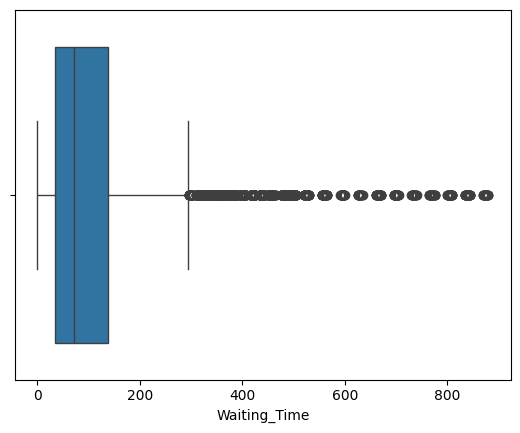

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='Waiting_Time',data=data)
plt.show()

In [10]:
data ['Waiting_Time']=data['Waiting_Time'].mask(data['Waiting_Time']>500,500 )

In [11]:
data['Charging_Type'] = data['Charging_Type'].map({'Fast': 1, 'Normal': 0})

In [12]:
data=data.drop(['Station_ID','Date'],axis=1)

CORRELATION MATRIX

In [14]:
corr_mat=data.corr(numeric_only=True)

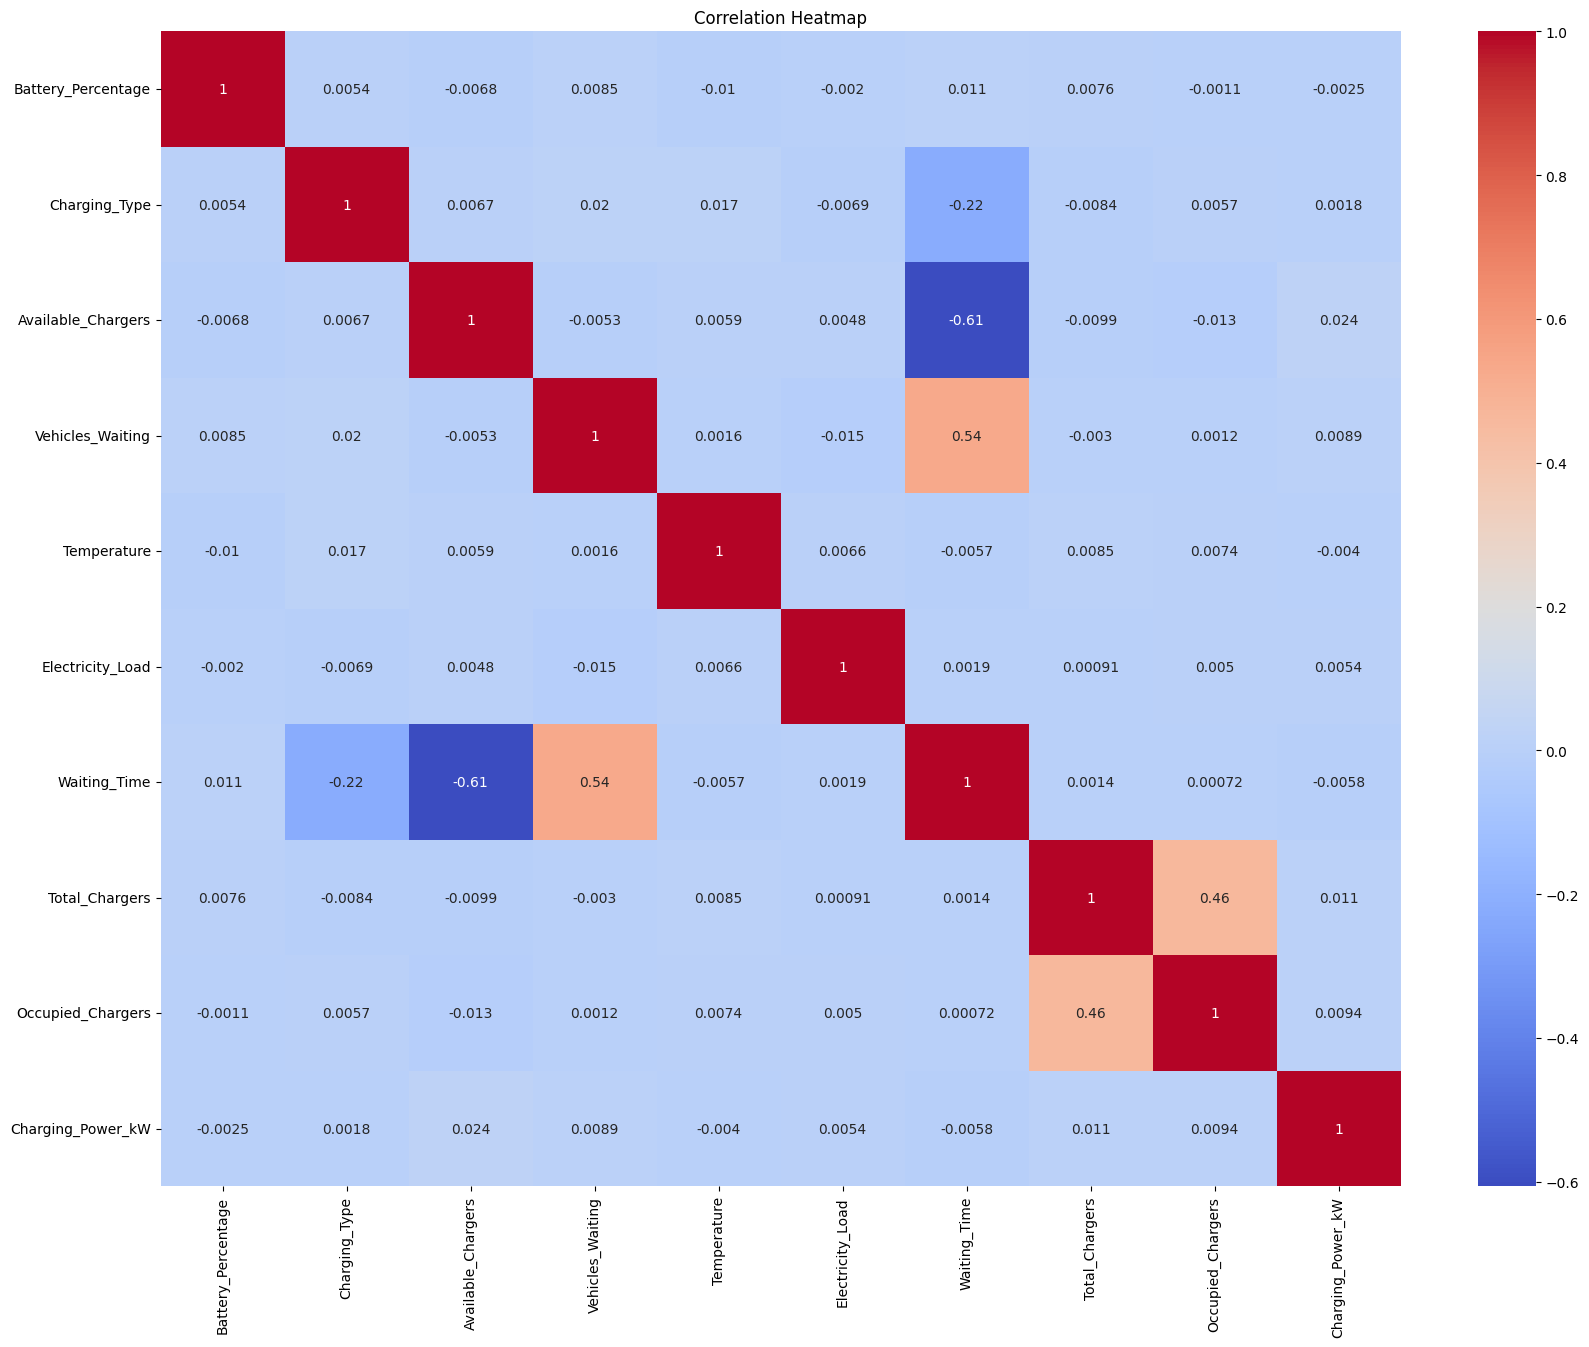

In [39]:
plt.figure(figsize=(20, 15))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm',)
plt.title('Correlation Heatmap')
plt.show()

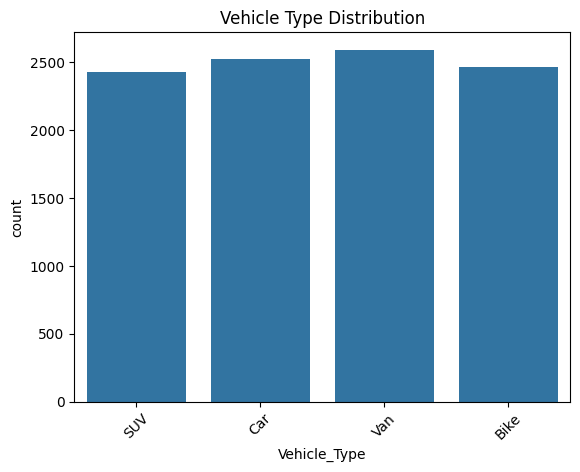

In [16]:
sns.countplot(x='Vehicle_Type', data=data)
plt.title("Vehicle Type Distribution")
plt.xticks(rotation=45)
plt.show()

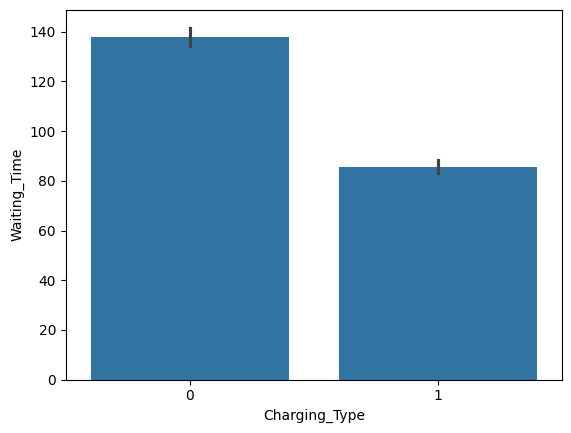

In [42]:
sns.barplot(x='Charging_Type', y='Waiting_Time', data=data)
plt.show()

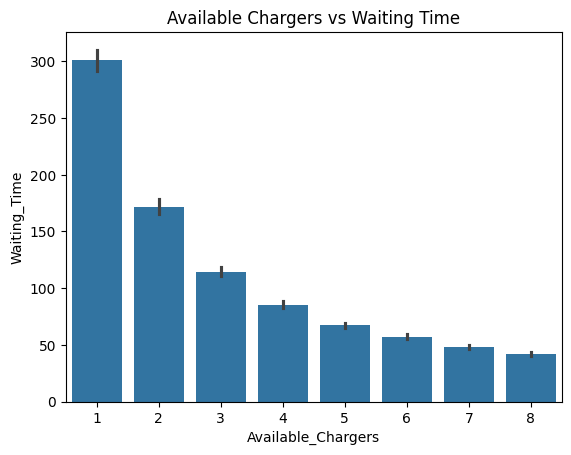

In [19]:

sns.barplot(x='Available_Chargers', y='Waiting_Time', data=data)
plt.title('Available Chargers vs Waiting Time')
plt.show()

In [20]:
data = pd.get_dummies(data,columns=['City','Time_Slot','Vehicle_Type','Weather','Holiday',
    'Traffic_Level'],drop_first=True)

In [21]:
X = data.drop('Waiting_Time', axis=1)

y = data['Waiting_Time']

SPLIT DATA INTO TRAIN/TEST SET

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

LINEAR REGRESSION

In [23]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [24]:
y_pred=reg.predict(X_test)

In [25]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6946526427320989

In [26]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 4353.263529273264


RIDGE REGRESSION

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
alpha=[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,5,10,20,30]
ridge=Ridge()
parameters={'alpha':alpha}
ridge_regressor=GridSearchCV(ridge,parameters)
ridge_regressor.fit(X_train,y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30]})

In [28]:
alpha = ridge_regressor.best_params_['alpha']
print(alpha)

30


In [29]:
ridge=Ridge(alpha=30)
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_test)

In [30]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6946263017961217

In [31]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 4353.63906563599


RANDOM FOREST REGRESSOR

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
reg=RandomForestRegressor()
n_estimators=[25,50,75,100,125,150,175,200]
criterion=['squared_error']
max_depth=[3,5,10]
parameters={'n_estimators':n_estimators,'criterion':criterion,'max_depth':max_depth}
FC_reg=GridSearchCV(reg,parameters)
FC_reg.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]})

In [33]:
FC_reg.best_params_

{'criterion': 'squared_error', 'max_depth': 10, 'n_estimators': 125}

In [34]:
from sklearn.metrics import r2_score
y_pred_rf = FC_reg.predict(X_test)
r2_score(y_test, y_pred_rf)

0.9992436270708734

In [35]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred_rf)
print("Mean Squared Error:", mse)

Mean Squared Error: 10.783426181767636


In [36]:
result = pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred})

In [37]:
result


,Actual Value,Predicted Value
6252,161,239.075835
4684,246,270.164474
1731,75,114.513911
4742,1,-25.310153
4521,232,244.944629
...,...,...
6412,60,40.433432
8285,97,174.783442
7853,162,196.385886
1095,90,150.656113
